### 导入数据集

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification  # 导入用于生成模拟分类数据集的函数

In [23]:
X, y = make_classification( # 生成一个二分类模拟数据集
    n_samples=200,          # 生成200个样本
    n_features=2,           # 每个样本包含2个特征
    n_redundant=0,          # 不生成冗余特征
    n_classes=2,            # 分类类别数量为2
    n_clusters_per_class=1, # 每个类别包含1个数据簇
    random_state=1024)      # 固定随机种子，保证结果可重复

In [24]:
X.shape, y.shape

((200, 2), (200,))

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True, stratify=y)

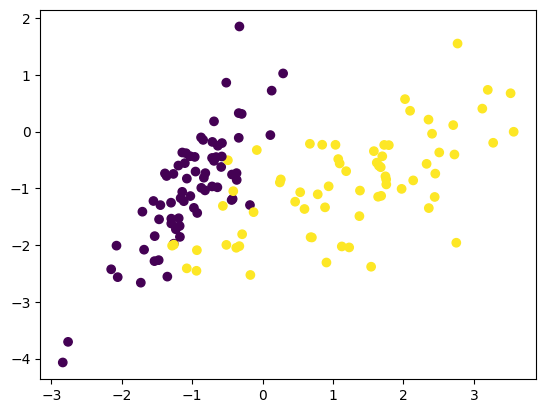

In [26]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.show()

### sklearn中的逻辑回归

In [27]:
from sklearn.linear_model import LogisticRegression  # 导入逻辑回归分类模型

In [28]:
clf = LogisticRegression()  # 创建逻辑回归模型
clf.fit(X_train, y_train);  # 使用训练集训练模型

In [29]:
clf.score(X_train, y_train)  # 计算模型在训练集上的准确率

0.9357142857142857

In [30]:
clf.score(X_test, y_test)  # 计算模型在测试集上的准确率

0.95

In [31]:
y_pred = clf.predict(X_test)  # 使用训练好的模型预测测试集的类别标签
y_pred

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [32]:
clf.predict_proba(X_test)  # 计算测试集中每个样本属于各个类别的概率

array([[6.16354809e-05, 9.99938365e-01],
       [9.70574901e-01, 2.94250991e-02],
       [1.52971106e-02, 9.84702889e-01],
       [9.66935836e-01, 3.30641638e-02],
       [7.08449171e-02, 9.29155083e-01],
       [1.04894437e-01, 8.95105563e-01],
       [6.91772786e-03, 9.93082272e-01],
       [2.84232933e-02, 9.71576707e-01],
       [2.30381015e-02, 9.76961899e-01],
       [8.18393626e-01, 1.81606374e-01],
       [8.00064923e-03, 9.91999351e-01],
       [1.05251820e-01, 8.94748180e-01],
       [9.65353903e-01, 3.46460966e-02],
       [9.03818739e-01, 9.61812611e-02],
       [8.57742151e-01, 1.42257849e-01],
       [8.62158334e-01, 1.37841666e-01],
       [8.18356847e-01, 1.81643153e-01],
       [9.89882070e-03, 9.90101179e-01],
       [9.58180589e-01, 4.18194115e-02],
       [9.23030797e-01, 7.69692026e-02],
       [7.92699729e-01, 2.07300271e-01],
       [1.59118103e-01, 8.40881897e-01],
       [5.18411945e-01, 4.81588055e-01],
       [9.07050697e-01, 9.29493034e-02],
       [2.517857

In [33]:
np.argmax(clf.predict_proba(X_test), axis=1)  # 找出每个样本预测概率最大的类别索引

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0])

### 超参数

In [34]:
from sklearn.model_selection import GridSearchCV  # 导入网格搜索工具，用于自动寻找最佳超参数组合

In [35]:
params = [{  # 定义逻辑回归模型需要搜索的参数组合
    'l1_ratio': [0],  # 0 表示纯 L2 正则化
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],  # 正则化强度的倒数。C 越小，正则化越强；C 越大，正则化越弱
    'solver': ['lbfgs']  # lbfgs 适合 L2 正则化
}, {
    'l1_ratio': [1],  # 1 表示纯 L1 正则化
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],  # 正则化强度的倒数。C 越小，正则化越强；C 越大，正则化越弱
    'solver': ['saga'],  # saga 支持 L1 正则化
    'max_iter': [1000]   # 最大迭代次数
}, {
    'C': [np.inf],  # C=∞ 表示不使用正则化
    'l1_ratio': [0],
    'solver': ['lbfgs']  # lbfgs 适合 L2 正则化或不使用正则化
}, {
    'l1_ratio': [0.25, 0.5, 0.75],  # 使用弹性网络正则化，即 L1 和 L2 的组合。表示L1 正则化在弹性网络中的占比。0 表示纯 L2，1 表示纯 L1
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['saga'],  # saga 支持 elasticnet 正则化
    'max_iter': [1000]  # 模型训练的最大迭代次数
}]

In [36]:
grid = GridSearchCV(                  # 创建网格搜索对象，用于寻找逻辑回归模型的最佳超参数组合
    estimator=LogisticRegression(),   # 指定需要调参的模型：逻辑回归
    param_grid=params,                # 指定需要搜索的超参数组合
    n_jobs=-1)                        # 使用全部 CPU 核心并行计算

In [37]:
grid.fit(X_train, y_train);  # 使用训练集进行网格搜索和模型训练

In [38]:
grid.best_score_  # 查看交叉验证中的最佳平均得分

np.float64(0.95)

In [39]:
grid.best_estimator_.score(X_test, y_test)  # 使用最佳模型在测试集上进行评估

0.9333333333333333

In [40]:
grid.best_params_  # 查看 GridSearchCV 搜索得到的最佳超参数组合

{'C': 1, 'l1_ratio': 0.75, 'max_iter': 1000, 'solver': 'saga'}